In [270]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score
from sklearn.model_selection import cross_val_score
plt.rcParams['font.sans-serif']='Simhei'
plt.rcParams['axes.unicode_minus']=False

In [271]:
df=pd.read_csv('./01titanic-data.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [272]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [273]:
df.fillna({'Age':df['Age'].median(),'Embarked':df['Embarked'].mode()[0]},inplace=True)

In [274]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [275]:
df['Sex']=df['Sex'].map({'male':0,'female':1})
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",1,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,28.0,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",0,26.0,0,0,111369,30.0000,C148,C


In [276]:
df['Embarked']=df['Embarked'].map({'C':0,'Q':1,'S':2})
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,0
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,2
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,2
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27.0,0,0,211536,13.0000,NaN,2
887,888,1,1,"Graham, Miss. Margaret Edith",1,19.0,0,0,112053,30.0000,B42,2
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,28.0,1,2,W./C. 6607,23.4500,NaN,2
889,890,1,1,"Behr, Mr. Karl Howell",0,26.0,0,0,111369,30.0000,C148,0


In [277]:
x=df[['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']]
x

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,0,22.0,1,0,7.2500,2
1,1,1,38.0,1,0,71.2833,0
2,3,1,26.0,0,0,7.9250,2
3,1,1,35.0,1,0,53.1000,2
4,3,0,35.0,0,0,8.0500,2
...,...,...,...,...,...,...,...
886,2,0,27.0,0,0,13.0000,2
887,1,1,19.0,0,0,30.0000,2
888,3,1,28.0,1,2,23.4500,2
889,1,0,26.0,0,0,30.0000,0


In [278]:
y=df['Survived']
y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

In [279]:
scaler=StandardScaler()
x_scaler=scaler.fit_transform(x)
x_scaler

array([[ 0.82737724, -0.73769513, -0.56573646, ..., -0.47367361,
        -0.50244517,  0.58595414],
       [-1.56610693,  1.35557354,  0.66386103, ..., -0.47367361,
         0.78684529, -1.9423032 ],
       [ 0.82737724,  1.35557354, -0.25833709, ..., -0.47367361,
        -0.48885426,  0.58595414],
       ...,
       [ 0.82737724,  1.35557354, -0.1046374 , ...,  2.00893337,
        -0.17626324,  0.58595414],
       [-1.56610693, -0.73769513, -0.25833709, ..., -0.47367361,
        -0.04438104, -1.9423032 ],
       [ 0.82737724, -0.73769513,  0.20276197, ..., -0.47367361,
        -0.49237783, -0.67817453]], shape=(891, 7))

In [280]:
x_train,x_test,y_train,y_test=train_test_split(x_scaler,y,test_size=0.2)
mode=LogisticRegression()
mode.fit(x_train,y_train)

LogisticRegression()

In [281]:
cross_val_score(mode,x_scaler,y,cv=5,scoring='accuracy')
y_pred=mode.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
accuracy

0.8212290502793296

In [282]:
mode.coef_[0]

array([-0.81284364,  1.27378308, -0.49585018, -0.30993999, -0.07516769,
        0.11476723, -0.11903713])

In [283]:
df1=pd.Series(mode.coef_[0],index=x.columns.values)

In [284]:
df1=df1.sort_values(ascending=False)

<BarContainer object of 7 artists>

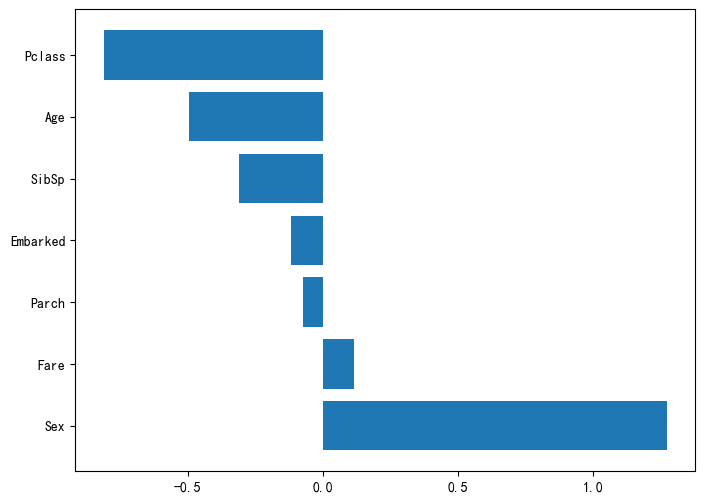

In [285]:
plt.figure(figsize=(8,6))
plt.barh(df1.index.values,df1.values)

In [286]:
df2=df[df.Survived==1]['Sex'].value_counts().rename({0:'男',1:'女'})

<BarContainer object of 2 artists>

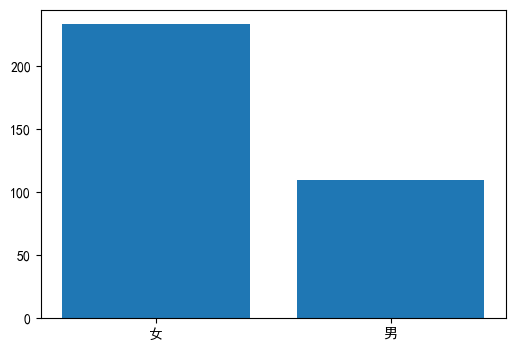

In [287]:
plt.figure(figsize=(6,4))
plt.bar(df2.index.values,df2.values)

In [289]:
df3=df[df.Survived==1]['Age'].value_counts()
df3

Age
28.00    59
24.00    15
22.00    11
27.00    11
35.00    11
         ..
0.67      1
43.00     1
11.00     1
0.42      1
47.00     1
Name: count, Length: 65, dtype: int64

(array([ 36.,  19.,  63., 117.,  52.,  24.,  21.,   9.,   0.,   1.]),
 array([ 0.42 ,  8.378, 16.336, 24.294, 32.252, 40.21 , 48.168, 56.126,
        64.084, 72.042, 80.   ]),
 <BarContainer object of 10 artists>)

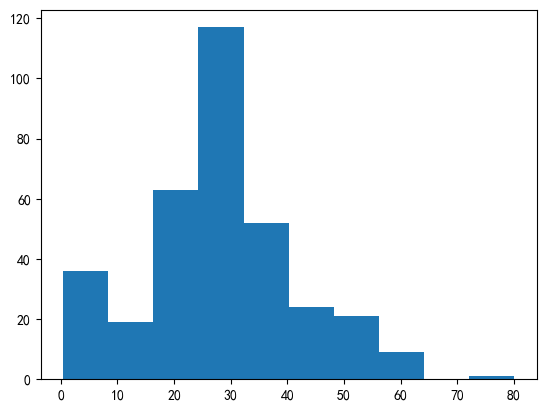

In [292]:
plt.hist(df[df.Survived==1]['Age'])

In [293]:
import seaborn as sns

<Axes: xlabel='Age', ylabel='Count'>

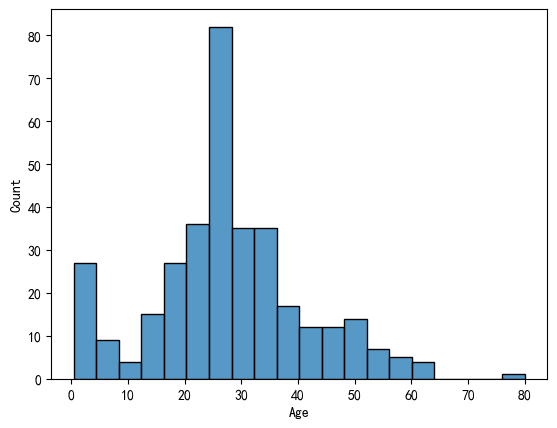

In [294]:
sns.histplot(df[df.Survived==1]['Age'])

<Axes: xlabel='Age', ylabel='Count'>

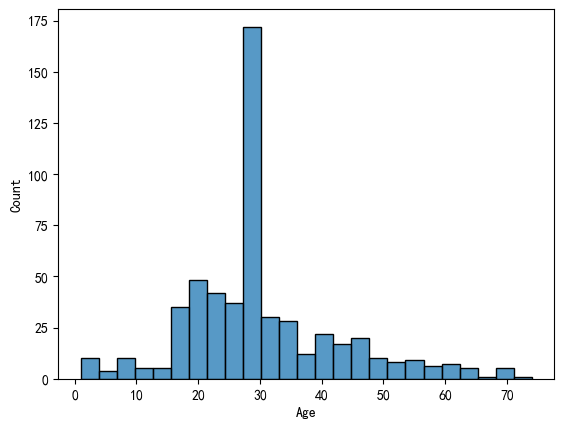

In [295]:
sns.histplot(df[df.Survived==0]['Age'])

<Axes: xlabel='Pclass', ylabel='Survived'>

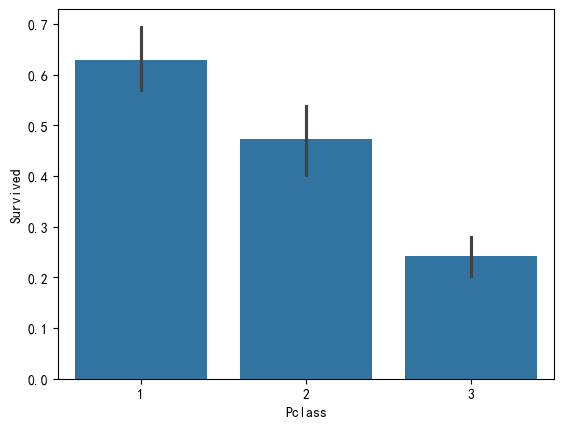

In [297]:
sns.barplot(x=df['Pclass'],y=df['Survived'])